In [ ]:
# =========================================================
# Standard library
# =========================================================
import os
import sys
import importlib
import subprocess
from pathlib import Path

# =========================================================
# Make local SIDM package + backgroundEst helpers importable
# =========================================================
def find_repo_root(start=None, repo_hint="SIDM_fresh"):
    """
    Find the repo root containing the local `sidm/` package.

    Handles both cases:
      1. Notebook is already inside the repo.
      2. Notebook starts from CMSSW src/ and repo is a child directory.
    """
    start = Path(start or os.getcwd()).resolve()

    # Search current directory and parents
    for path in [start, *start.parents]:
        if (path / "sidm").is_dir():
            return path

    # Search one level below current directory, useful from CMSSW src/
    for child in start.iterdir():
        if child.is_dir() and (child / "sidm").is_dir():
            return child

    # Try known repo name directly
    hinted = start / repo_hint
    if (hinted / "sidm").is_dir():
        return hinted

    raise RuntimeError(
        f"Could not find a `sidm/` directory from {start}. "
        "Check your repo location with `!find . -maxdepth 3 -type d -name sidm`."
    )


REPO_ROOT = find_repo_root()
BACKGROUND_EST_DIR = REPO_ROOT / "sidm" / "studies" / "backgroundEst"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

if str(BACKGROUND_EST_DIR) not in sys.path:
    sys.path.insert(0, str(BACKGROUND_EST_DIR))

print(f"Using SIDM repo root: {REPO_ROOT}")
print(f"Using backgroundEst helper dir: {BACKGROUND_EST_DIR}")
print("analysis_tools exists:", (BACKGROUND_EST_DIR / "analysis_tools.py").exists())

# =========================================================
# Columnar analysis
# =========================================================
import awkward as ak
import numpy as np
import coffea.util
from coffea import processor
from coffea.util import load

# =========================================================
# Local SIDM imports
# =========================================================
from sidm.tools import (
    utilities,
    sidm_processor,
    scaleout,
    cutflow,
    llpnanoaodschema,
)

# Reload local SIDM modules during development
for module in (
    utilities,
    sidm_processor,
    scaleout,
    cutflow,
    llpnanoaodschema,
):
    importlib.reload(module)

# Import/reload backgroundEst helper module
import analysis_tools as at
importlib.reload(at)

# =========================================================
# Plotting / notebook utilities
# =========================================================
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

utilities.set_plot_style()
%matplotlib inline

Using SIDM repo root: /uscms_data/d3/scampbel/CMSSW_14_1_0_pre4/src/SIDM_fresh


/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value

ModuleNotFoundError: No module named 'analysis_tools'

In [2]:
from pathlib import Path
import sys

REPO = Path("/uscms_data/d3/scampbel/CMSSW_14_1_0_pre4/src/SIDM_fresh")
TOOLS_DIR = REPO / "sidm/studies/backgroundEst"

print("analysis_tools exists:", (TOOLS_DIR / "analysis_tools.py").exists())
print("tools dir:", TOOLS_DIR)

if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

import analysis_tools as at

analysis_tools exists: True
tools dir: /uscms_data/d3/scampbel/CMSSW_14_1_0_pre4/src/SIDM_fresh/sidm/studies/backgroundEst


In [2]:

def run(cmd, check=True):
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if result.stdout.strip():
        print(result.stdout.strip())
    if result.stderr.strip():
        print(result.stderr.strip())
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed: {' '.join(cmd)}")
    return result

def xrdcp_from_eos(eos_path, local_path):
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)

    if not local_path.exists():
        run(["xrdcp", "-f", f"root://cmseos.fnal.gov/{eos_path}", str(local_path)])

    return local_path

In [3]:
EOS_DIR = "/store/user/scampbel/sidm_condor/BackgroundMergedGroupsCollapsed_abcd_weighted_v1"
CACHE = Path("notebook_coffea_cache/background_groups_collapsed_abcd_weighted_v1")

files = {
    "QCD": f"{EOS_DIR}/QCD.coffea",
    "DY": f"{EOS_DIR}/DY.coffea",
    "TTJets": f"{EOS_DIR}/TTJets.coffea",
}

backgrounds = {}

for name, eos_path in files.items():
    local_path = CACHE / f"{name}.coffea"
    xrdcp_from_eos(eos_path, local_path)
    backgrounds[name] = load(local_path)

qcd = backgrounds["QCD"]
dy = backgrounds["DY"]
ttjets = backgrounds["TTJets"]

In [5]:
backgrounds = {}

for eos_path in background_group_paths:
    name = Path(eos_path).stem   # QCD, DY, TTJets
    local_path = LOCAL_CACHE / Path(eos_path).name

    xrdcp_from_eos(eos_path, local_path)

    print(f"Loading {name} from {local_path}")
    backgrounds[name] = load(local_path)

backgrounds.keys()

+ xrdcp -f root://cmseos.fnal.gov//store/user/scampbel/sidm_condor/BackgroundMergedGroups_abcd_weighted_v1/DY.coffea notebook_coffea_cache/background_groups_abcd_weighted_v1/DY.coffea
Loading DY from notebook_coffea_cache/background_groups_abcd_weighted_v1/DY.coffea
+ xrdcp -f root://cmseos.fnal.gov//store/user/scampbel/sidm_condor/BackgroundMergedGroups_abcd_weighted_v1/QCD.coffea notebook_coffea_cache/background_groups_abcd_weighted_v1/QCD.coffea
Loading QCD from notebook_coffea_cache/background_groups_abcd_weighted_v1/QCD.coffea
+ xrdcp -f root://cmseos.fnal.gov//store/user/scampbel/sidm_condor/BackgroundMergedGroups_abcd_weighted_v1/TTJets.coffea notebook_coffea_cache/background_groups_abcd_weighted_v1/TTJets.coffea
Loading TTJets from notebook_coffea_cache/background_groups_abcd_weighted_v1/TTJets.coffea


dict_keys(['DY', 'QCD', 'TTJets'])

In [4]:
qcd = backgrounds["QCD"]
dy = backgrounds["DY"]
ttjets = backgrounds["TTJets"]

In [13]:
testHist = qcd['out']['QCD']['hists']['egm_lj_pt']['2mu2e_noLjCount', :]

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f1a26d4ed30>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

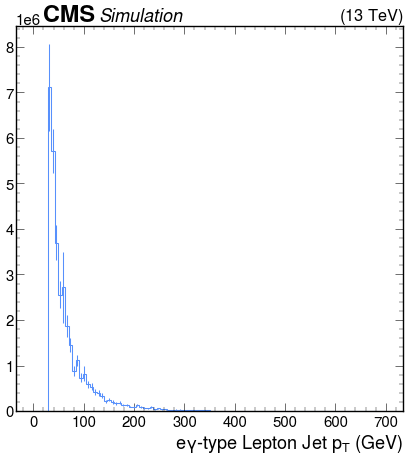

In [14]:
utilities.plot(testHist)